In [1]:
import numpy as np
import pandas as pd

ca_meta = pd.read_csv('../ca/df/ca_meta.csv')
gla_meta = ca_meta[(ca_meta.District == 7) | (ca_meta.District == 8) | (ca_meta.District == 12)]
gla_meta = gla_meta.reset_index()
gla_meta = gla_meta.drop(columns=['index'])
gla_meta.to_csv('gla_meta.csv', index=False)
print(gla_meta[gla_meta.duplicated(subset=['Lat', 'Lng'])])
gla_meta

Empty DataFrame
Columns: [ID, Lat, Lng, District, County, Fwy, Lanes, Type, Direction, ID2]
Index: []


,ID,Lat,Lng,District,County,Fwy,Lanes,Type,Direction,ID2
0,767494,34.103332,-118.249733,7,Los Angeles,SR2-E,3,Mainline,E,3527
1,767509,34.107693,-118.249538,7,Los Angeles,SR2-E,4,Mainline,E,3528
2,767523,34.113959,-118.242956,7,Los Angeles,SR2-E,4,Mainline,E,3529
3,767541,34.116060,-118.238384,7,Los Angeles,SR2-E,4,Mainline,E,3530
4,767554,34.121074,-118.229892,7,Los Angeles,SR2-E,4,Mainline,E,3531
...,...,...,...,...,...,...,...,...,...,...
3829,1202527,33.800970,-118.082822,12,Orange,I605-N,4,Mainline,N,8595
3830,1202549,33.804853,-118.081293,12,Orange,I605-N,4,Mainline,N,8596
3831,1219560,33.799259,-118.084891,12,Orange,I605-S,5,Mainline,S,8597
3832,1202522,33.801040,-118.083136,12,Orange,I605-S,4,Mainline,S,8598


In [2]:
gla_meta_id2 = gla_meta.ID2.values.tolist()
print(len(gla_meta_id2))

ca_rn_adj = np.load('../ca/df/ca_rn_adj.npy')
print(ca_rn_adj.shape)

gla_rn_adj = ca_rn_adj[gla_meta_id2]
gla_rn_adj = gla_rn_adj[:,gla_meta_id2]
print(gla_rn_adj.shape)

np.save('gla_rn_adj.npy', gla_rn_adj)

3834
(8600, 8600)
(3834, 3834)


In [ ]:
year = 'raw_2021'  # please specify the year, our experiments use 2019

gla_meta.ID = gla_meta.ID.astype(str)
gla_meta_id = gla_meta.ID.values.tolist()

ca_his = pd.read_hdf('../ca/df/ca_his_' + year +'.h5')
gla_his = ca_his[gla_meta_id]
gla_his

,767494,767509,767523,767541,767554,767572,767620,767455,768202,767470,...,1221523,1221550,1221536,1221556,1219551,1202527,1202549,1219560,1202522,1202537
Time,,,,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00,23.0,78.0,26.0,71.0,23.0,68.0,15.0,17.0,12.0,16.0,...,64.0,52.0,33.0,36.0,28.0,28.0,26.0,50.0,32.0,33.0
2021-01-01 00:05:00,16.0,79.0,22.0,67.0,21.0,79.0,20.0,22.0,11.0,19.0,...,77.0,67.0,43.0,42.0,24.0,20.0,22.0,57.0,33.0,33.0
2021-01-01 00:10:00,14.0,107.0,44.0,71.0,19.0,105.0,36.0,38.0,12.0,22.0,...,75.0,55.0,41.0,44.0,41.0,40.0,34.0,42.0,31.0,29.0
2021-01-01 00:15:00,11.0,90.0,33.0,82.0,19.0,123.0,45.0,49.0,13.0,46.0,...,80.0,51.0,34.0,37.0,52.0,44.0,44.0,65.0,52.0,51.0
2021-01-01 00:20:00,15.0,107.0,56.0,105.0,18.0,113.0,44.0,44.0,16.0,49.0,...,103.0,85.0,60.0,58.0,85.0,83.0,75.0,86.0,51.0,52.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-31 23:35:00,79.0,86.0,85.0,85.0,108.0,42.0,130.0,33.0,30.0,61.0,...,194.0,127.0,106.0,86.0,89.0,82.0,75.0,134.0,94.0,80.0
2021-12-31 23:40:00,57.0,100.0,80.0,90.0,123.0,41.0,146.0,42.0,27.0,49.0,...,165.0,111.0,111.0,89.0,89.0,80.0,77.0,107.0,78.0,68.0
2021-12-31 23:45:00,82.0,90.0,79.0,82.0,86.0,41.0,124.0,38.0,34.0,54.0,...,163.0,102.0,105.0,70.0,68.0,54.0,61.0,82.0,57.0,46.0


In [6]:
gla_his.to_hdf('gla_his_' + year + '.h5', key='t', mode='w')
gla_his.shape

(105120, 3834)

In [7]:
# code for checking adj stat
gla_rn_adj = np.load('gla_rn_adj.npy')
node_num = gla_rn_adj.shape[0]

print(gla_rn_adj[0,0])
gla_rn_adj[np.arange(node_num), np.arange(node_num)] = 0
print(gla_rn_adj[0,0])

print('edge number', np.count_nonzero(gla_rn_adj))
print('node degree', np.mean(np.count_nonzero(gla_rn_adj, axis=-1)))
print('sparsity', np.count_nonzero(gla_rn_adj) / (node_num**2) * 100)

1.0
0.0
edge number 98703
node degree 25.74413145539906
sparsity 0.6714692607042008


In [8]:
for year in ['raw_2017', 'raw_2018', 'raw_2019', 'raw_2020']:
    gla_meta.ID = gla_meta.ID.astype(str)
    gla_meta_id = gla_meta.ID.values.tolist()

    ca_his = pd.read_hdf('../ca/df/ca_his_' + year +'.h5')
    gla_his = ca_his[gla_meta_id]
    gla_his
    gla_his.to_hdf('gla_his_' + year + '.h5', key='t', mode='w')
    gla_his.shape
    # code for checking adj stat
    gla_rn_adj = np.load('gla_rn_adj.npy')
    node_num = gla_rn_adj.shape[0]

    print(gla_rn_adj[0,0])
    gla_rn_adj[np.arange(node_num), np.arange(node_num)] = 0
    print(gla_rn_adj[0,0])

    print('edge number', np.count_nonzero(gla_rn_adj))
    print('node degree', np.mean(np.count_nonzero(gla_rn_adj, axis=-1)))
    print('sparsity', np.count_nonzero(gla_rn_adj) / (node_num**2) * 100)

1.0
0.0
edge number 98703
node degree 25.74413145539906
sparsity 0.6714692607042008
1.0
0.0
edge number 98703
node degree 25.74413145539906
sparsity 0.6714692607042008
1.0
0.0
edge number 98703
node degree 25.74413145539906
sparsity 0.6714692607042008
1.0
0.0
edge number 98703
node degree 25.74413145539906
sparsity 0.6714692607042008


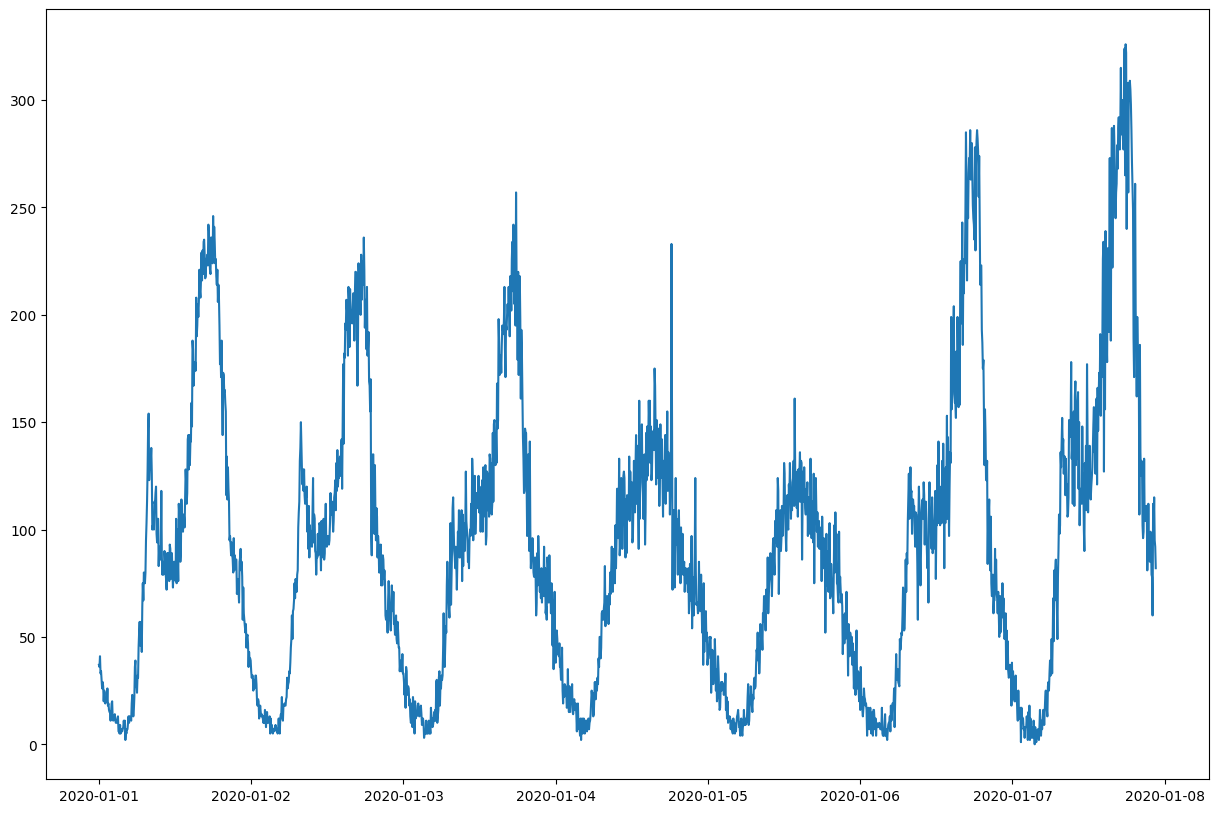

In [15]:
# plot the data
import matplotlib.pyplot as plt

# Plot the first 1000 rows of the dataset
plt.figure(figsize=(15, 10))


plt.plot(gla_his.iloc[:2000, 0])

In [16]:
gla_his

,767494,767509,767523,767541,767554,767572,767620,767455,768202,767470,...,1221523,1221550,1221536,1221556,1219551,1202527,1202549,1219560,1202522,1202537
Time,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,37.0,53.0,110.0,125.0,91.0,103.0,76.0,39.0,41.0,72.0,...,155.0,94.0,62.0,65.0,63.0,56.0,62.0,21.0,49.0,46.0
2020-01-01 00:05:00,36.0,47.0,97.0,108.0,82.0,86.0,68.0,34.0,35.0,66.0,...,142.0,89.0,64.0,67.0,44.0,39.0,68.0,17.0,63.0,75.0
2020-01-01 00:10:00,41.0,60.0,102.0,109.0,94.0,95.0,78.0,40.0,39.0,59.0,...,129.0,98.0,63.0,63.0,54.0,45.0,62.0,17.0,63.0,89.0
2020-01-01 00:15:00,33.0,52.0,97.0,113.0,87.0,93.0,73.0,43.0,40.0,73.0,...,162.0,128.0,85.0,91.0,115.0,54.0,93.0,103.0,101.0,99.0
2020-01-01 00:20:00,34.0,51.0,91.0,101.0,69.0,67.0,55.0,31.0,31.0,59.0,...,233.0,180.0,114.0,120.0,144.0,141.0,127.0,98.0,105.0,103.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-31 23:35:00,27.0,124.0,67.0,106.0,29.0,106.0,41.0,43.0,30.0,47.0,...,129.0,108.0,66.0,66.0,53.0,46.0,42.0,97.0,67.0,59.0
2020-12-31 23:40:00,29.0,127.0,67.0,108.0,29.0,90.0,28.0,30.0,14.0,27.0,...,92.0,76.0,53.0,53.0,41.0,32.0,30.0,72.0,51.0,50.0
2020-12-31 23:45:00,21.0,116.0,57.0,113.0,27.0,111.0,40.0,42.0,20.0,32.0,...,100.0,88.0,57.0,60.0,41.0,36.0,35.0,71.0,49.0,42.0


In [18]:
!pip install pandas seaborn matplotlib numpy

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np



# Read the data, assuming each column is a feature and each row is a time step
df = gla_his

# If there's a datetime column in the DataFrame, remove it (assuming the column name is 'date')
if 'date' in df.columns:
    df = df.drop('date', axis=1)

# Ensure the DataFrame contains only numeric data
df = df.select_dtypes(include=[np.number])

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Print the correlation matrix
print(correlation_matrix)

# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(30, 30))  # Adjust the size of the heatmap as needed
sns.heatmap(correlation_matrix, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap of Correlation Matrix')
plt.show()